# Hierarchical forecasting with `pymc_forecast`

This notebook ports the upstream NumPyro hierarchical forecasting example (itself a port
of Pyro's [Forecasting III: hierarchical models](https://pyro.ai/examples/forecasting_iii.html))
to the PyMC API. It generalizes the
[univariate notebook](forecasting_univariate.ipynb) from a single series to a panel: we
forecast hourly **BART arrivals to one destination** (`EMBR`, Embarcadero) from all 50
origin stations at once.

Each origin keeps its own random-walk level and its own weekly seasonal profile, but all
series share the drift scale and the observation scale — that sharing is what pools
information across stations. Where the NumPyro version expresses the hierarchy with
`numpyro.plate`, here the batch structure is a **named dim**: latents carry
`dims=("origin",)`, and every result comes back as a labeled `(time, origin)` array.

## Prepare notebook

In [1]:
import logging
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    Forecaster,
    ForecastingModel,
    Horizon,
    build_model,
    eval_crps,
    evaluate_forecast,
    null_covariates,
    periodic_repeat,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM
from pymc_forecast.datasets import load_bart_od

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

SEED = 42

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
NUM_STEPS = 200 if SMOKE_TEST else 25_000
NUM_SAMPLES = 50 if SMOKE_TEST else 500

## Read data

We window the complete hourly origin-destination panel to the last 90 training days plus
two test weeks, select arrivals to `EMBR` from every origin, and apply `log1p` — it tames
the multiplicative daily swings while staying defined at zero rides. The result is a
labeled `(time, origin)` array.

In [2]:
PERIOD = 24 * 7
TRAIN_DAYS = 90
TEST_HOURS = 2 * PERIOD
WINDOW = TRAIN_DAYS * 24 + TEST_HOURS

od = load_bart_od()
arrivals = od.sel(destination="EMBR").isel({TIME_DIM: slice(-WINDOW, None)})
y = np.log1p(arrivals.astype("float64"))
time_values = y[TIME_DIM].values
print("panel:", dict(y.sizes))
print("window:", time_values[0], "->", time_values[-1])

panel: {'time': 2496, 'origin': 50}
window: 2019-09-19T00:00:00 -> 2019-12-31T23:00:00


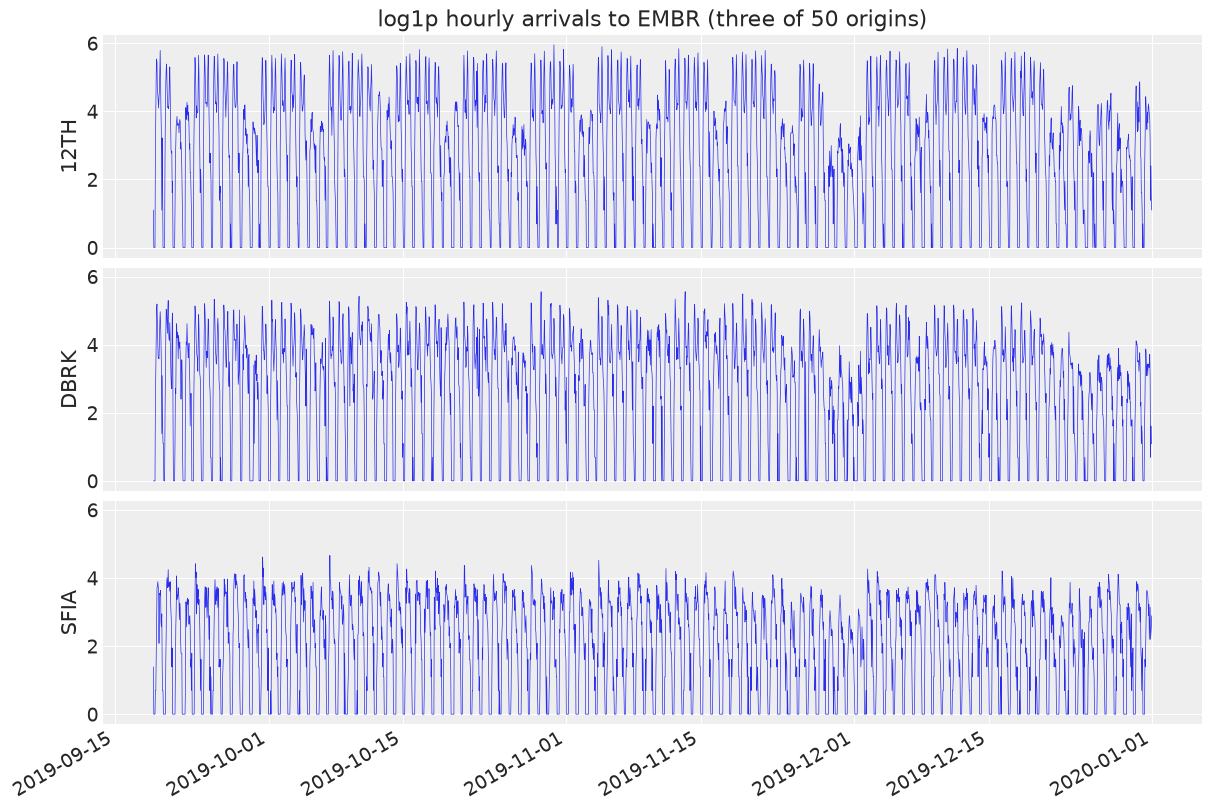

In [3]:
SHOW_ORIGINS = ["12TH", "DBRK", "SFIA"]

fig, axes = plt.subplots(len(SHOW_ORIGINS), 1, figsize=(12, 8), sharex=True, sharey=True)
for ax, origin in zip(axes, SHOW_ORIGINS, strict=True):
    series = y.sel(origin=origin)
    ax.plot(time_values, series.values, lw=0.5, color="C0")
    ax.set_ylabel(origin)
axes[0].set_title("log1p hourly arrivals to EMBR (three of 50 origins)")
fig.autofmt_xdate()
plt.show()

## Train-test split

Hold out the last two weeks (336 hours) for testing.

In [4]:
y_train = y.isel({TIME_DIM: slice(None, -TEST_HOURS)})
y_test = y.isel({TIME_DIM: slice(-TEST_HOURS, None)})
print("train:", dict(y_train.sizes), "test:", dict(y_test.sizes))

train: {'time': 2160, 'origin': 50} test: {'time': 336, 'origin': 50}


## Model specification

This is the univariate local-level model lifted to a panel. Each origin $s$ gets its own
random-walk level $\ell_{t,s}$ and its own weekly seasonal profile (one value per
hour-of-week, 168 per origin), while the drift scale and the observation scale are
shared:

$$
\begin{aligned}
\mu_{t,s} &= \ell_{t,s} + \text{seasonal}_{(t \bmod 168),\,s} \\
\ell_{t,s} &= \ell_{t-1,s} + \sigma_\text{drift}\,\delta_{t,s},
  \qquad \delta_{t,s} \sim \text{Normal}(0, 1) \\
y_{t,s} &\sim \text{Normal}(\mu_{t,s}, \sigma)
\end{aligned}
$$

Two things carry the hierarchy in `pymc_forecast`:

- `time_series(..., dims=("origin",))` samples the drift once per time step **per
  origin** — and creates the matching `drift_raw_future` variable with the same batch
  dim on the forecast horizon.
- The seasonal profile is a plain PyMC variable with dims
  `("hour_of_week", "origin")`, registered on a coord the model body adds itself, then
  tiled over the horizon with `periodic_repeat`.

The `"origin"` coord itself is registered automatically from the data's non-time dims.

In [5]:
class HierarchicalLocalLevel(ForecastingModel):
    """Per-origin local level + weekly seasonality with shared scales."""

    def model(self, h: Horizon, covariates: xr.DataArray) -> None:
        pm.modelcontext(None).add_coord("hour_of_week", np.arange(PERIOD))

        drift_scale = pm.LogNormal("drift_scale", -20.0, 5.0, initval=0.01)
        sigma = pm.LogNormal("sigma", -5.0, 5.0, initval=0.05)
        seasonal = pm.Normal("seasonal", 0.0, 5.0, dims=("hour_of_week", "origin"))

        drift_raw = self.time_series(
            "drift_raw",
            lambda name, dims: pm.Normal(name, 0.0, 1.0, dims=dims),
            dims=("origin",),
        )
        level = pt.cumsum(drift_raw * drift_scale, axis=0)
        prediction = level + periodic_repeat(seasonal, h.duration, axis=0, period=PERIOD)

        self.predict(
            lambda name, mu, dims, observed: pm.Normal(
                name, mu, sigma, dims=dims, observed=observed
            ),
            prediction,
        )


model = HierarchicalLocalLevel()
build_model(model, y_train, null_covariates(y_train[TIME_DIM].values))

drift_scale ~ LogNormal(-20, 5)
      sigma ~ LogNormal(-5, 5)
   seasonal ~ Normal(0, 5)
  drift_raw ~ Normal(0, 1)
        obs ~ Normal(f(seasonal, drift_raw, drift_scale), sigma)

## Inference with ADVI

The model has one latent per hour per origin (plus 168 seasonal values per origin), about
120k parameters in total — routine for mean-field ADVI. The model learns seasonality from
the time index alone, so no covariates are needed anywhere.

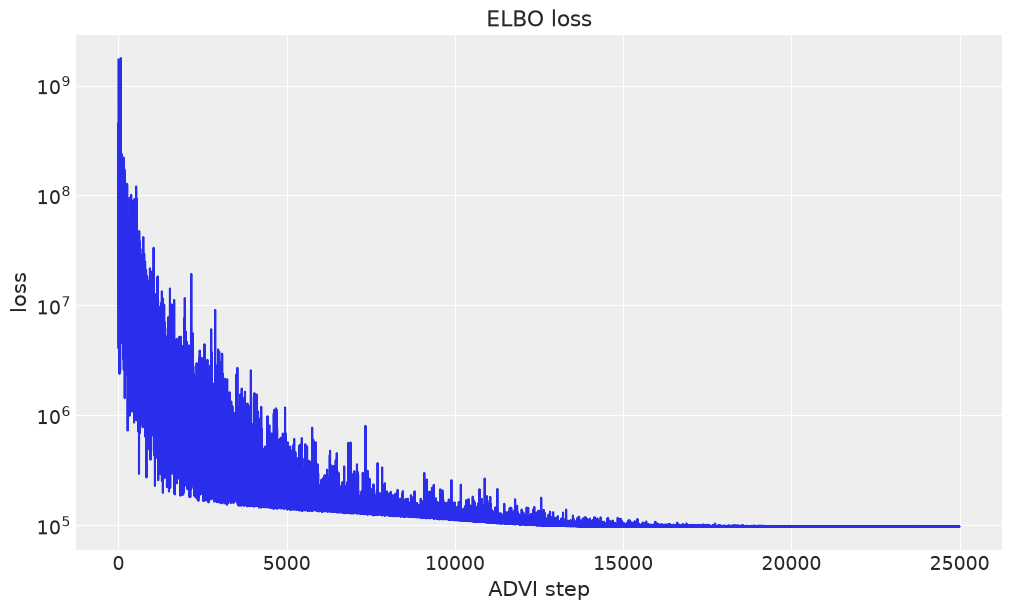

In [6]:
forecaster = Forecaster(
    model,
    y_train,
    optimizer=0.01,
    num_steps=NUM_STEPS,
    random_seed=SEED,
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="ADVI step", ylabel="loss", yscale="log")
plt.show()

## Forecast and evaluation

For a covariate-free model, `horizon=` extends the training index at its own spacing.
The forecast comes back with dims `(chain, draw, time_future, origin)`, and
`evaluate_forecast` aligns prediction and truth **by dim name** — the same call as in
the univariate case, now scoring all 50 series at once.

In [7]:
forecast_idata = forecaster.forecast(
    horizon=TEST_HOURS,
    num_samples=NUM_SAMPLES,
    random_seed=SEED,
)
forecast = forecast_idata["predictions"]["forecast"]
print("forecast dims:", dict(forecast.sizes))

truth = y_test.rename({TIME_DIM: FUTURE_DIM})
print("test:", evaluate_forecast(forecast, truth))

forecast dims: {'chain': 1, 'draw': 500, 'time_future': 336, 'origin': 50}


test: {'mae': 0.4723723899756811, 'rmse': 0.8130504290770938, 'crps': 0.3821998891162727, 'coverage': 0.8188690476190477}


## Per-origin scores

Because everything is labeled, per-series diagnostics are one `sel` away: score each
origin separately and see where the pooled model does well or poorly.

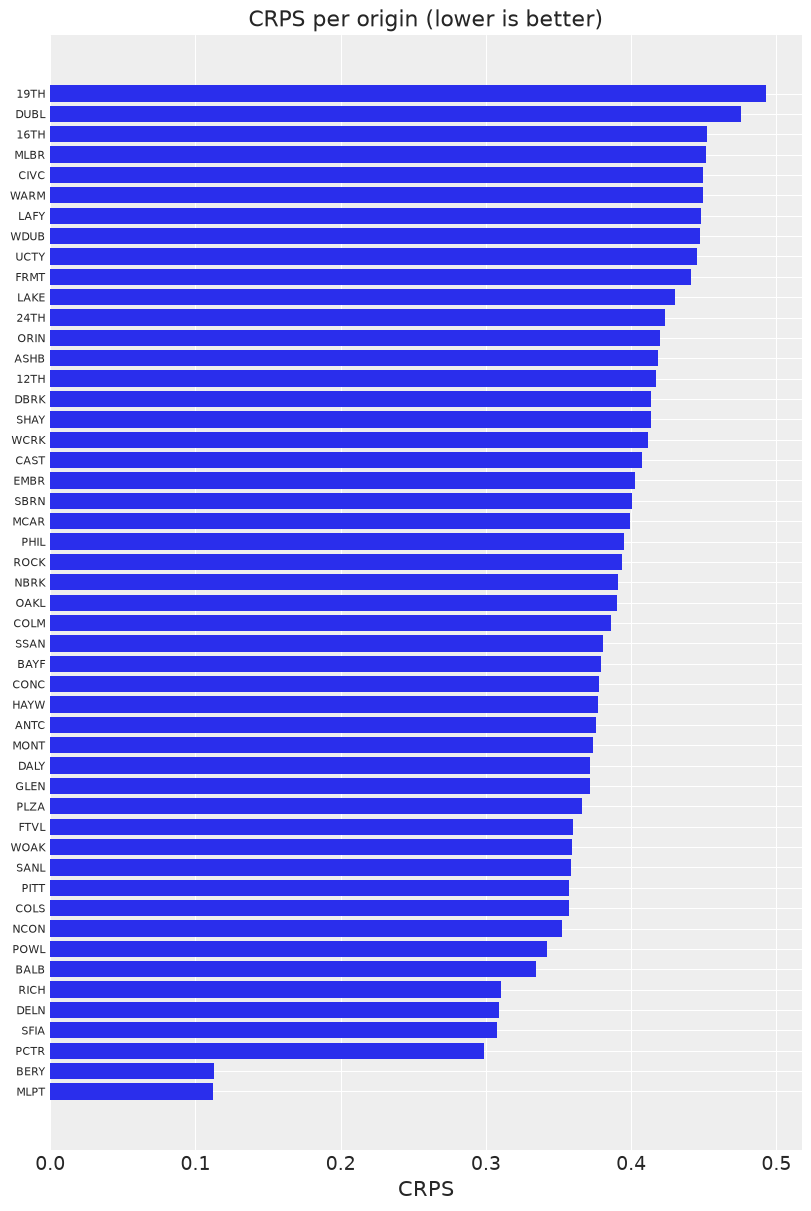

In [8]:
per_origin = {
    str(origin): eval_crps(forecast.sel(origin=origin), truth.sel(origin=origin))
    for origin in y["origin"].values
}
crps_sorted = sorted(per_origin.items(), key=lambda kv: kv[1])

fig, ax = plt.subplots(figsize=(8, 12))
names = [name for name, _ in crps_sorted]
values = [value for _, value in crps_sorted]
ax.barh(names, values, color="C0")
ax.set(title="CRPS per origin (lower is better)", xlabel="CRPS")
ax.tick_params(axis="y", labelsize=8)
plt.show()

## Forecast visualization

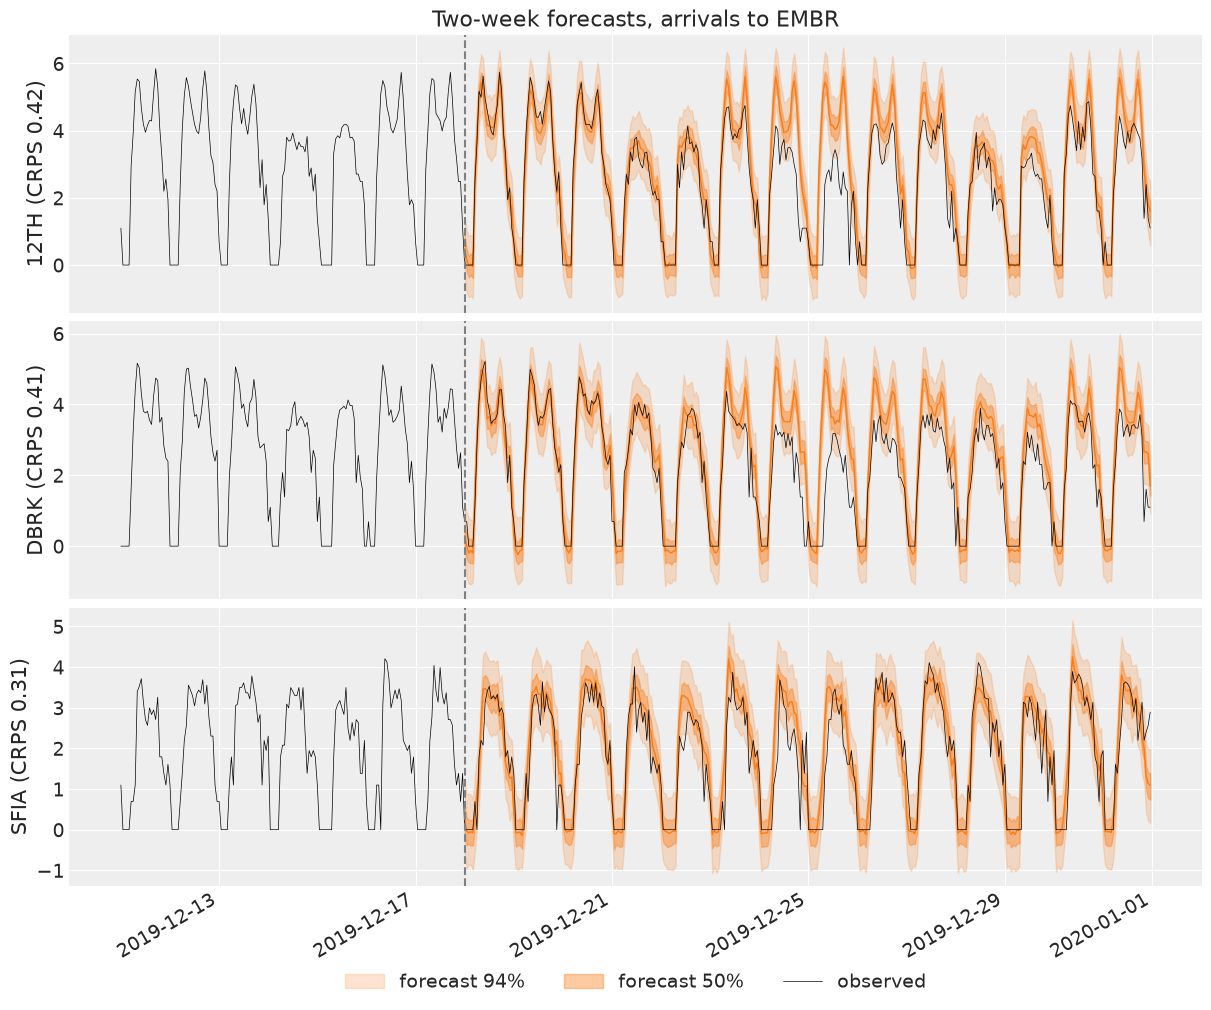

In [9]:
def plot_band(ax, samples, dim, color, label):
    """Median line and 50% / 94% quantile bands of a (chain, draw, time) array."""
    time_axis = samples[dim].values
    quantiles = samples.quantile([0.03, 0.25, 0.5, 0.75, 0.97], dim=("chain", "draw"))
    ax.fill_between(
        time_axis,
        quantiles.sel(quantile=0.03),
        quantiles.sel(quantile=0.97),
        color=color,
        alpha=0.2,
        label=f"{label} 94%",
    )
    ax.fill_between(
        time_axis,
        quantiles.sel(quantile=0.25),
        quantiles.sel(quantile=0.75),
        color=color,
        alpha=0.4,
        label=f"{label} 50%",
    )
    ax.plot(time_axis, quantiles.sel(quantile=0.5), color=color, lw=1)


ZOOM_HOURS = TEST_HOURS + PERIOD

fig, axes = plt.subplots(len(SHOW_ORIGINS), 1, figsize=(12, 10), sharex=True)
for ax, origin in zip(axes, SHOW_ORIGINS, strict=True):
    plot_band(ax, forecast.sel(origin=origin), FUTURE_DIM, "C1", "forecast")
    zoom = y.sel(origin=origin).isel({TIME_DIM: slice(-ZOOM_HOURS, None)})
    ax.plot(zoom[TIME_DIM].values, zoom.values, color="black", lw=0.5, label="observed")
    ax.axvline(truth[FUTURE_DIM].values[0], color="gray", ls="--")
    ax.set_ylabel(f"{origin} (CRPS {per_origin[origin]:.2f})")
axes[0].set_title("Two-week forecasts, arrivals to EMBR")
axes[-1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
fig.autofmt_xdate()
plt.show()

The pooled model tracks each origin's own weekly rhythm — commuter-heavy stations keep
their sharp weekday double peak, quieter ones their flatter profile — while the shared
scales keep the per-origin forecasts regularized.

## References

- Upstream NumPyro notebook: <https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/hierarchical_forecasting_1.ipynb>
- Juan Orduz, *Hierarchical forecasting with NumPyro (part I)*: <https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/>
- Pyro, *Forecasting III: hierarchical models*: <https://pyro.ai/examples/forecasting_iii.html>